In [33]:
df = pd.read_csv("op_analysis.csv")

In [34]:
%matplotlib inline
import pandas as pd # for using pandas daraframe
import numpy as np # for som math operations
from sklearn.preprocessing import StandardScaler # for standardizing the Data
from sklearn.decomposition import PCA # for PCA calculation
import matplotlib.pyplot as plt # for plotting

In [35]:
df.describe()

,Member Count,Count Script,Sum Dispensed Quantity,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,...,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
count,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,...,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,13239.000000,13239.0,13239.000000
mean,9.179696,18.702772,923.773822,118707.178186,51.602236,1.636017,69.355497,0.457750,17.558355,0.141347,...,0.019574,1.764333,0.030549,0.002119,0.047580,0.001643,0.000013,0.204652,0.0,0.003100
std,16.931506,48.571346,3247.378661,44039.096216,33.041049,0.895364,81.807441,0.617814,41.378225,0.199806,...,0.087341,14.337894,0.150650,0.028128,0.138673,0.024117,0.000805,0.280436,0.0,0.028308
min,1.000000,1.000000,0.500000,12.000000,1.000000,1.000000,0.500000,0.022472,0.048780,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,2.000000,2.000000,44.000000,107453.500000,18.000000,1.000000,16.000000,0.100000,2.407407,0.015625,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,4.000000,6.000000,152.000000,122384.000000,63.000000,1.250000,40.800000,0.200000,6.345238,0.064516,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076923,0.0,0.000000
75%,9.000000,15.000000,614.000000,148504.000000,82.000000,2.000000,92.260417,0.900000,17.627107,0.173913,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.0,0.000000
max,296.000000,1534.000000,134140.000000,182198.000000,91.000000,14.000000,1520.000000,17.044444,1490.444444,1.000000,...,1.000000,827.000000,1.000000,1.000000,1.000000,1.000000,0.062500,1.000000,0.0,1.000000


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13239 entries, 0 to 13238
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Member Count            13239 non-null  int64  
 1   Count Script            13239 non-null  int64  
 2   Sum Dispensed Quantity  13239 non-null  float64
 3   Max Dispense Date       13239 non-null  object 
 4   Min Dispense Date       13239 non-null  object 
 5   PRSCRB_PROV_LOC_ID      13239 non-null  int64  
 6   Total Days              13239 non-null  int64  
 7   PR2                     13239 non-null  float64
 8   PR1                     13239 non-null  float64
 9   PR4                     13239 non-null  float64
 10  PR3                     13239 non-null  float64
 11  PR5                     13239 non-null  float64
 12  PR6                     13239 non-null  float64
 13  PR7                     13239 non-null  int64  
 14  PR8                     13239 non-null

In [37]:
df.shape

(13239, 32)

In [38]:
df.head(5)

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,...,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,7,7,301.0,2020-03-30,2020-01-25,130843,66,1.000000,43.000000,0.106061,...,0.000000,0,0.5,0.0,0.142857,0.0,0.0,0.285714,0,0.0
1,11,24,778.0,2020-03-31,2020-01-02,107152,90,2.181818,70.727273,0.266667,...,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0
2,9,16,391.0,2020-03-31,2020-01-06,128217,86,1.777778,43.444444,0.186047,...,0.222222,4,0.8,0.0,0.000000,0.0,0.0,0.000000,0,0.0
3,21,22,399.0,2020-03-26,2020-01-01,106985,86,1.047619,19.000000,0.255814,...,0.047619,2,0.0,0.0,0.047619,0.0,0.0,0.333333,0,0.0
4,11,20,711.0,2020-03-26,2020-01-07,171977,80,1.818182,64.636364,0.250000,...,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.272727,0,0.0


In [39]:
obs = df.isnull().sum().sort_values(ascending = False)
percent = round(df.isnull().sum().sort_values(ascending = False)/len(df)*100, 2)
pd.concat([obs, percent], axis = 1,keys= ['Number of Observations', 'Percent'])

,Number of Observations,Percent
PR30,0,0.0
PR29,0,0.0
Count Script,0,0.0
Sum Dispensed Quantity,0,0.0
Max Dispense Date,0,0.0
Min Dispense Date,0,0.0
PRSCRB_PROV_LOC_ID,0,0.0
Total Days,0,0.0
PR2,0,0.0
PR1,0,0.0


In [11]:
df.head(5)

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,...,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,7,7,301.0,2020-03-30,2020-01-25,130843,66,1.000000,43.000000,0.106061,...,0.000000,0,0.5,0.0,0.142857,0.0,0.0,0.285714,0,0.0
1,11,24,778.0,2020-03-31,2020-01-02,107152,90,2.181818,70.727273,0.266667,...,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0
2,9,16,391.0,2020-03-31,2020-01-06,128217,86,1.777778,43.444444,0.186047,...,0.222222,4,0.8,0.0,0.000000,0.0,0.0,0.000000,0,0.0
3,21,22,399.0,2020-03-26,2020-01-01,106985,86,1.047619,19.000000,0.255814,...,0.047619,2,0.0,0.0,0.047619,0.0,0.0,0.333333,0,0.0
4,11,20,711.0,2020-03-26,2020-01-07,171977,80,1.818182,64.636364,0.250000,...,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.272727,0,0.0


In [40]:
df2=df.drop(columns=['Max Dispense Date', 'Min Dispense Date', 'PRSCRB_PROV_LOC_ID'])

In [41]:
X = df2.values # getting all values as a matrix of dataframe 
sc = StandardScaler() # creating a StandardScaler object
X_std = sc.fit_transform(X) # standardizing the data

In [42]:
pca = PCA()
X_pca = pca.fit(X_std)

Text(0, 0.5, 'cumulative explained variance')

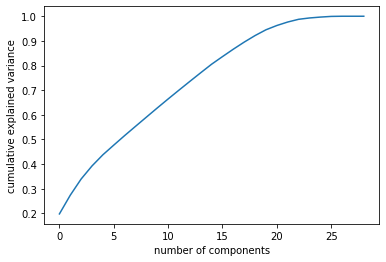

In [43]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

In [44]:
pca = PCA(n_components = 0.60)
X_pca = pca.fit_transform(X_std) # this will fit and reduce dimensions
print(pca.n_components_) # one can print and see how many components are selected. In this case it is 4 same as above we saw in step 5

10


In [45]:
n_pcs= pca.n_components_ # get number of component
# get the index of the most important feature on EACH component
most_important = [np.abs(pca.components_[i]).argmax() for i in range(n_pcs)]
initial_feature_names = df.columns
# get the most important feature names
most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]

In [46]:
pd.DataFrame(pca.components_, columns = df2.columns)

,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,...,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,0.366661,0.411946,0.413161,0.140605,0.193925,0.199837,0.323294,0.366353,0.026374,-0.005663,...,0.040103,0.221628,-0.024620,0.038420,0.048347,0.022414,0.015698,0.024419,-0.0,0.066021
1,0.060398,0.057673,0.055772,-0.439174,-0.519140,-0.483605,0.323677,0.142956,0.049989,-0.055280,...,-0.034819,0.104022,0.105659,-0.018719,-0.034818,-0.024120,-0.004466,0.147912,0.0,-0.188713
2,-0.049748,-0.050639,-0.041105,-0.114417,-0.013487,-0.014503,0.015605,-0.012000,0.630531,0.144753,...,0.083611,-0.007394,0.120460,-0.076115,0.078454,-0.052214,0.011239,-0.089381,0.0,0.071416
3,-0.051747,-0.046984,-0.050363,-0.009719,0.040499,0.013274,-0.053728,-0.062987,0.041170,0.211266,...,0.364547,0.004643,-0.168217,0.198244,0.412792,0.150565,0.023769,0.555341,-0.0,0.158863
4,-0.228040,-0.101040,0.019204,-0.378141,0.011436,0.179155,0.154383,0.189461,-0.122432,0.481830,...,0.016156,-0.057274,-0.007898,-0.325720,0.095867,-0.183253,-0.014705,-0.216777,0.0,0.397533
5,0.083810,0.031185,0.010717,0.227503,-0.091453,-0.091701,-0.140637,-0.099077,0.095602,0.161194,...,-0.270443,0.069191,0.056988,-0.062159,-0.142823,-0.332190,-0.268584,0.124249,0.0,0.334939
6,0.059403,0.021172,0.022568,0.187097,-0.065143,-0.062728,-0.113982,-0.060254,0.012684,-0.196820,...,0.301103,0.038733,0.216793,-0.338104,0.340614,-0.378374,0.183732,-0.127185,0.0,-0.099825
7,0.039638,0.012486,0.004866,0.103691,-0.006241,-0.040252,-0.067276,-0.053216,0.034093,0.066031,...,-0.047313,0.025464,0.267460,0.031793,-0.153373,-0.009401,0.556146,0.012487,-0.0,0.035288
8,-0.048690,-0.024020,0.002865,-0.058705,-0.020221,0.006647,0.015026,0.028225,-0.047687,-0.136881,...,-0.181162,-0.015800,-0.487549,-0.274071,0.014270,-0.222924,0.516187,0.027305,0.0,-0.103216
9,-0.094834,-0.034694,0.007788,-0.178991,0.020471,0.070165,0.097060,0.091163,-0.087775,-0.205749,...,0.240476,-0.129870,0.064113,-0.226252,-0.057585,0.383191,-0.203585,-0.138254,0.0,-0.073356


In [47]:
n_pcs= pca.n_components_ # get number of component
# get the index of the most important feature on EACH component
most_important = [np.abs(pca.components_[i]).argmax() for i in range(n_pcs)]
initial_feature_names = df2.columns
# get the most important feature names
most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]

In [48]:
print(most_important_names)

['Sum Dispensed Quantity', 'PR2', 'PR5', 'PR28', 'PR6', 'PR8', 'PR9', 'PR18', 'PR27', 'PR26']


In [55]:
#standardize the data to normal distribution
from sklearn import preprocessing
df2_standardized = preprocessing.scale(df2)
dataset1_standardized = pd.DataFrame(df2_standardized)


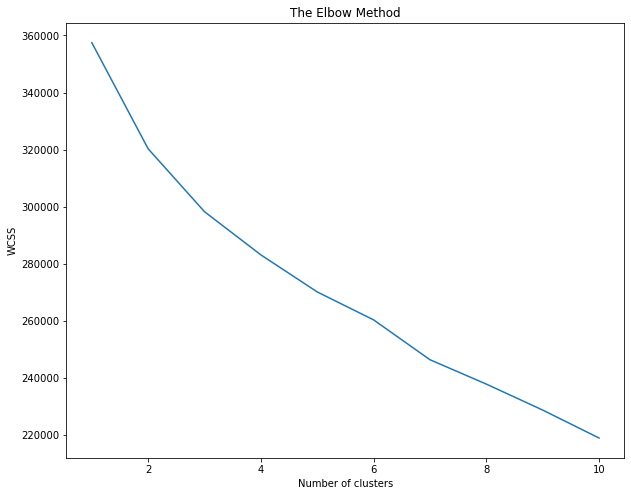

In [56]:
# find the appropriate cluster number
plt.figure(figsize=(10, 8))
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(dataset1_standardized)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [58]:
# Fitting K-Means to the dataset
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(dataset1_standardized)
#beginning of  the cluster numbering with 1 instead of 0
y_kmeans1=y_kmeans
y_kmeans1=y_kmeans+1
# New Dataframe called cluster
cluster = pd.DataFrame(y_kmeans1)
# Adding cluster to the Dataset1
df2['cluster'] = cluster
#Mean of clusters
kmeans_mean_cluster = pd.DataFrame(round(df2.groupby('cluster').mean(),1))
kmeans_mean_cluster

,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,...,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
cluster,,,,,,,,,,,,,,,,,,,,,
1,7.3,9.1,192.2,42.2,1.2,32.1,0.4,10.4,0.5,0.1,...,0.0,1.0,0.1,0.0,0.1,0.0,0.0,0.2,0.0,0.0
2,3.9,4.5,110.3,34.0,1.1,30.0,0.5,12.0,0.1,0.0,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0
3,67.5,173.3,9548.1,87.4,2.7,164.2,2.0,114.0,0.2,0.0,...,0.0,14.5,0.0,0.0,0.1,0.0,0.0,0.3,0.0,0.0
4,10.7,24.0,1263.9,77.1,2.4,132.0,0.3,16.0,0.1,0.0,...,0.0,1.6,0.0,0.0,0.1,0.0,0.0,0.1,0.0,0.0
5,165.3,606.6,43717.2,88.6,3.7,266.3,6.8,491.4,0.3,0.0,...,0.1,148.5,0.0,0.0,0.2,0.0,0.0,0.4,0.0,0.0


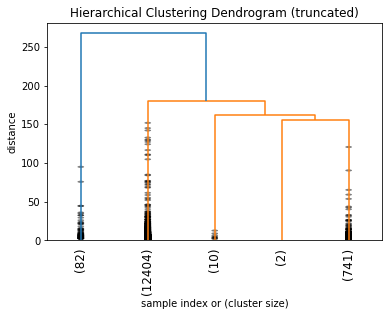

In [59]:
# Hierarchical clustering for the same dataset
# creating a dataset for hierarchical clustering
dataset2_standardized = dataset1_standardized
# needed imports
from scipy.cluster.hierarchy import dendrogram, linkage

# some setting for this notebook to actually show the graphs inline
# you probably won't need this
%matplotlib inline
np.set_printoptions(precision=5, suppress=True)  # suppress scientific float notation
#creating the linkage matrix
H_cluster = linkage(dataset2_standardized,'ward')
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index or (cluster size)')
plt.ylabel('distance')
dendrogram(
    H_cluster,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=5,  # show only the last p merged clusters
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)
plt.show()

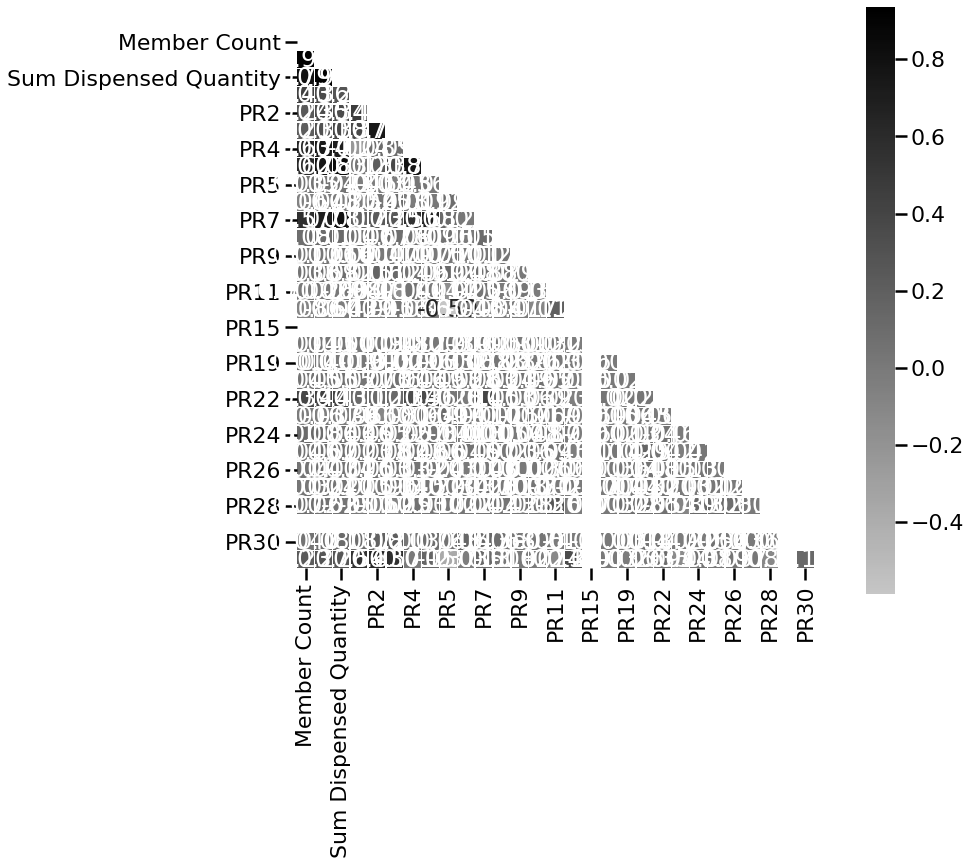

In [67]:
#More prominent correlation plot
import seaborn as sns
corr = df2.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f, ax = plt.subplots(figsize=(12, 12))
cmap = sns.light_palette('black', as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=None, center=0,square=True, annot=True, linewidths=.5, cbar_kws={"shrink": .9})

In [68]:
sc=StandardScaler()
data_scaled=sc.fit_transform(df2)

In [69]:
pc = PCA(svd_solver='auto')
pc.fit(data_scaled)
print('Total no. of principal components =',pc.n_components_)

Total no. of principal components = 30


In [70]:
#Print Principal Components
print('Principal Component Matrix :\n',pc.components_)

Principal Component Matrix :
 [[ 0.35917  0.40395  0.40489  0.16001  0.21474  0.21809  0.30529  0.35475
   0.00786 -0.00691  0.33365  0.05946  0.00912  0.05079 -0.01782 -0.02449
  -0.       0.00719  0.00145  0.03813  0.21452 -0.03055  0.03868  0.04686
   0.02329  0.01532  0.01768 -0.       0.06965  0.17002]
 [ 0.08114  0.08371  0.08579 -0.36659 -0.40068 -0.36649  0.29388  0.15526
   0.24823  0.00459  0.1371   0.00932  0.00476  0.00209  0.11642 -0.23566
   0.       0.00525  0.02715  0.0129   0.10405  0.1088  -0.01834  0.00903
  -0.02306  0.00257  0.11499  0.      -0.10466 -0.49088]
 [-0.06221 -0.06126 -0.0519   0.08811  0.2109   0.19617 -0.12091 -0.06532
   0.54858  0.15674  0.00871  0.08256  0.01933  0.21762 -0.36624 -0.53549
  -0.       0.02481 -0.00485  0.09736 -0.04776  0.0573  -0.05158  0.0921
  -0.03095  0.01275 -0.12879  0.       0.1529  -0.10555]
 [-0.0484  -0.04366 -0.04763  0.02094  0.06703  0.03871 -0.07024 -0.06739
   0.00532  0.20401 -0.00455  0.10563  0.12319  0.1946   0.3

In [71]:
#The amount of variance that each PC explains
var = pc.explained_variance_ratio_
print(var)

[0.19526 0.09252 0.06556 0.05125 0.04362 0.03779 0.0373  0.0362  0.03595
 0.03588 0.03525 0.03463 0.03424 0.03384 0.03333 0.02974 0.02917 0.02769
 0.02565 0.02261 0.01681 0.01367 0.0112  0.00903 0.00521 0.00336 0.00262
 0.00063 0.      0.     ]


Text(0, 0.5, 'Explained Variance Ratio')

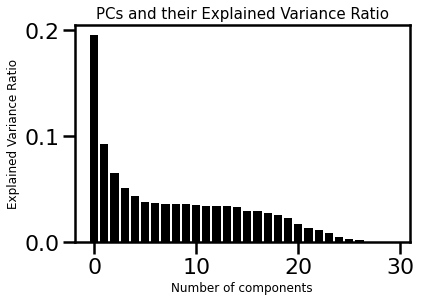

In [72]:
#Plot explained variance ratio for each PC
plt.bar([i for i, _ in enumerate(var)],var,color='black')
plt.title('PCs and their Explained Variance Ratio', fontsize=15)
plt.xlabel('Number of components',fontsize=12)
plt.ylabel('Explained Variance Ratio',fontsize=12)

In [73]:
#Cumulative Variance explained by each PC
cum_var = np.cumsum(np.round(pc.explained_variance_ratio_, decimals=4)*100)
print(cum_var)

[ 19.53  28.78  35.34  40.46  44.82  48.6   52.33  55.95  59.55  63.14
  66.67  70.13  73.55  76.93  80.26  83.23  86.15  88.92  91.49  93.75
  95.43  96.8   97.92  98.82  99.34  99.68  99.94 100.   100.   100.  ]


Text(0, 0.5, 'Cumulative Explained Variance Ratio')

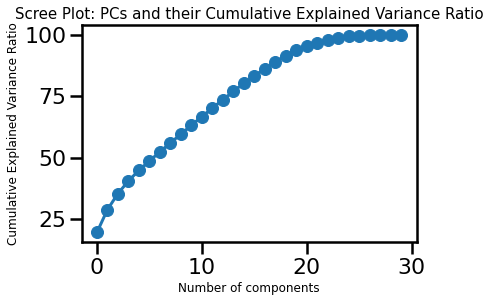

In [74]:
# Scree Plot
plt.plot(cum_var, marker='o')
plt.title('Scree Plot: PCs and their Cumulative Explained Variance Ratio',fontsize=15)
plt.xlabel('Number of components',fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio',fontsize=12)

C:\Users\colto\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:143: FutureWarning: The sklearn.metrics.classification module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.metrics. Anything that cannot be imported from sklearn.metrics is now part of the private API.
  warnings.warn(message, FutureWarning)


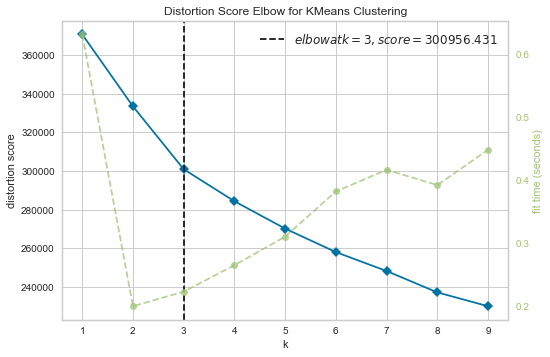

In [76]:
#Plotting Elbow Curve
from yellowbrick.cluster import KElbowVisualizer


model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))
visualizer.fit(data_scaled)    
visualizer.poof()

In [77]:
#Fitting data into K-Means model with 3 clusters
km_3=KMeans(n_clusters=3,random_state=12345)
km_3.fit(data_scaled)
print(km_3.cluster_centers_)

[[-0.26035 -0.26927 -0.24458 -0.47025 -0.53066 -0.47695 -0.02312 -0.14488
   0.12197  0.01835 -0.12633 -0.04105 -0.00342 -0.03059  0.17837 -0.08804
   0.      -0.00131  0.01502 -0.0133  -0.07992  0.09663 -0.05425 -0.02916
  -0.03115 -0.0159   0.09694  0.      -0.10782 -0.71626]
 [ 0.31951  0.305    0.25423  0.79417  0.8823   0.78716 -0.09453  0.10564
  -0.22539 -0.02833  0.06699  0.04917  0.00342  0.03838 -0.32128  0.16581
   0.      -0.00476 -0.02773  0.01335  0.04863 -0.1639   0.08886  0.03732
   0.04799  0.02245 -0.17941  0.       0.17086  1.22385]
 [ 6.7792   8.31183  8.71482  1.15347  2.01203  2.10602  6.88207  7.45967
   0.69184 -0.18155  7.78854  1.13046  0.12832  0.75373  0.5869  -0.65917
   0.       0.35973  0.08373  0.49835  4.60793 -0.20105  0.27365  0.68137
   0.31221  0.26386  0.56434  0.       0.83851  1.03137]]


In [78]:
print(km_3.labels_)

[0 1 0 ... 0 0 0]


In [79]:
pd.Series(km_3.labels_).value_counts()

0    8342
1    4803
2      94
dtype: int64

In [80]:
# calculate Silhouette Coefficient for K=3
from sklearn import metrics
metrics.silhouette_score(data_scaled, km_3.labels_)

0.19312033388527303

In [81]:
# calculate SC for K=2 through K=10
k_range = range(2, 10)
scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=12345)
    km.fit(data_scaled)
    scores.append(metrics.silhouette_score(data_scaled, km.labels_))

In [82]:
print(scores)

[0.7383096758914386, 0.19312033388527303, 0.18861566363021165, 0.18967434763593957, 0.191822706811806, 0.19424308021434109, 0.1965769278120056, 0.20952859676047406]


In [83]:
from sklearn.metrics import davies_bouldin_score, silhouette_score, silhouette_samples
sse,db,slc = {}, {}, {}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000,random_state=12345).fit(data_scaled)
    if k == 4: labels = kmeans.labels_
    clusters = kmeans.labels_
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
    db[k] = davies_bouldin_score(data_scaled,clusters)
    slc[k] = silhouette_score(data_scaled,clusters)

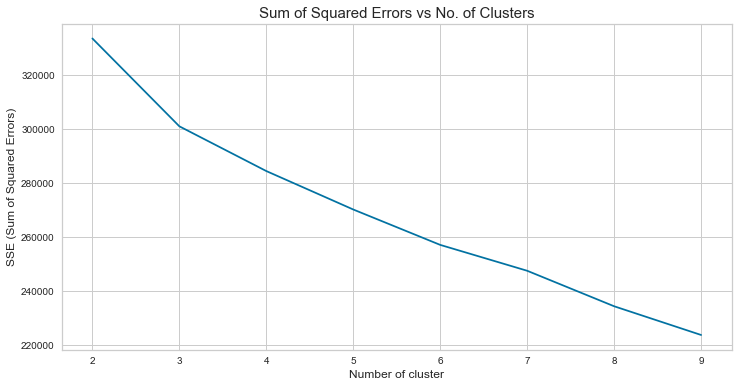

In [84]:
#Plotting SSE
plt.figure(figsize=(12,6))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("SSE (Sum of Squared Errors)", fontsize=12)
plt.title("Sum of Squared Errors vs No. of Clusters", fontsize=15)
plt.show()

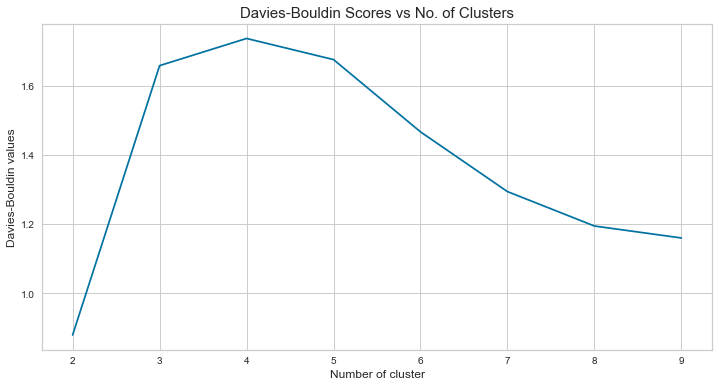

In [85]:
#Plotting Davies-Bouldin Scores
plt.figure(figsize=(12,6))
plt.plot(list(db.keys()), list(db.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("Davies-Bouldin values", fontsize=12)
plt.title("Davies-Bouldin Scores vs No. of Clusters", fontsize=15)
plt.show()

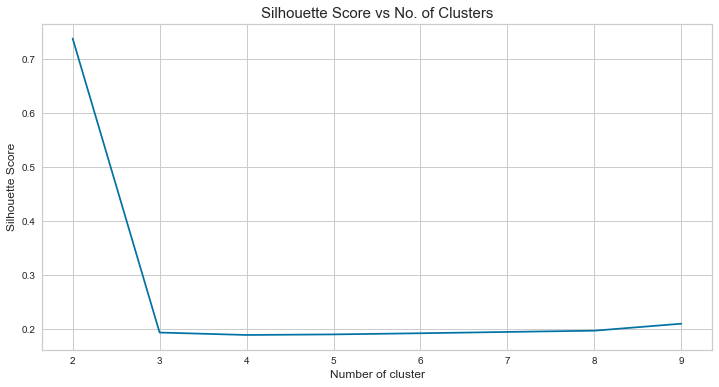

In [86]:
plt.figure(figsize=(12,6))
plt.plot(list(slc.keys()), list(slc.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score vs No. of Clusters", fontsize=15)
plt.show()

For n_clusters = 2 The average silhouette_score is : 0.7383096758914386
For n_clusters = 3 The average silhouette_score is : 0.19312033388527303
For n_clusters = 4 The average silhouette_score is : 0.18861566363021165
For n_clusters = 5 The average silhouette_score is : 0.18967434763593957
For n_clusters = 6 The average silhouette_score is : 0.191822706811806
For n_clusters = 7 The average silhouette_score is : 0.19424308021434109
For n_clusters = 8 The average silhouette_score is : 0.1965769278120056
For n_clusters = 9 The average silhouette_score is : 0.20952859676047406


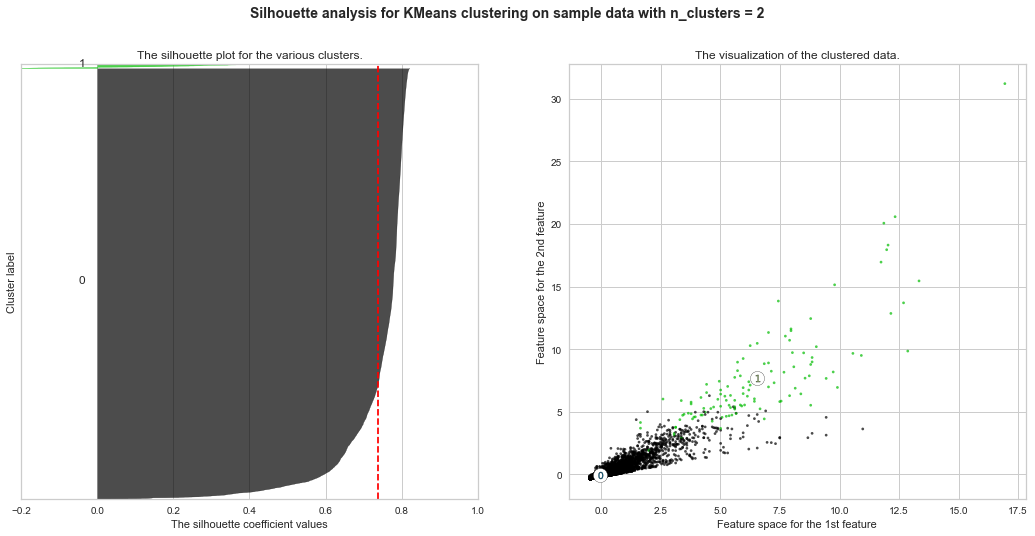

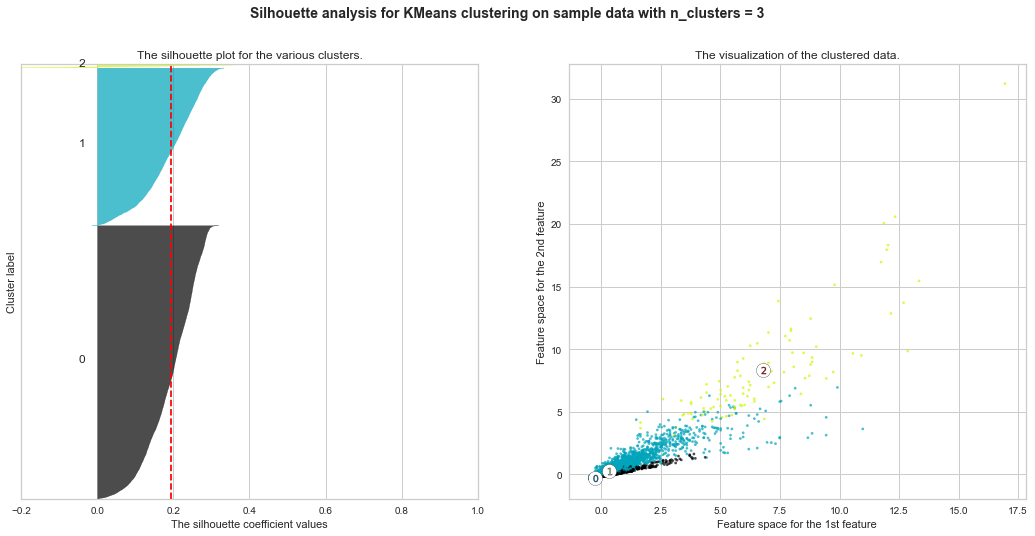

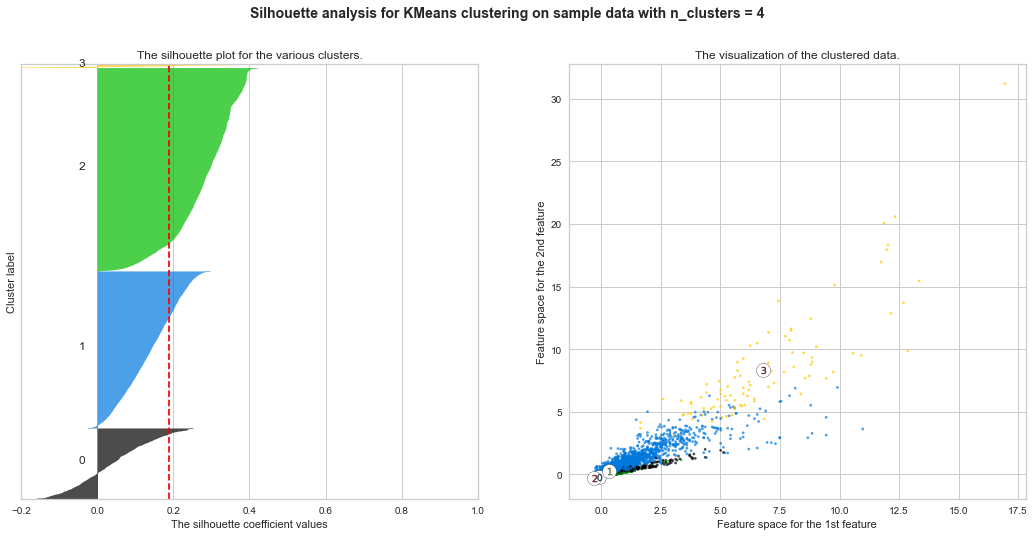

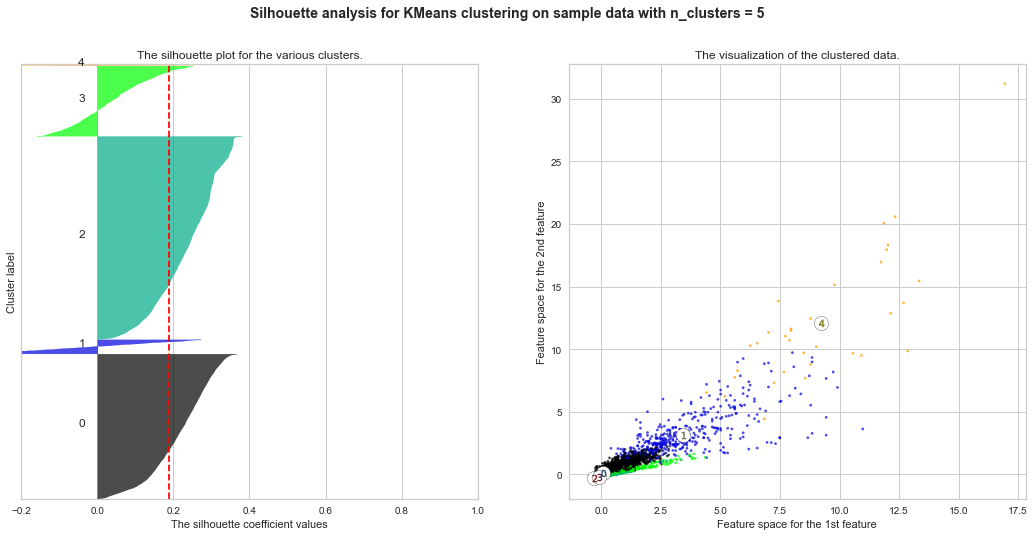

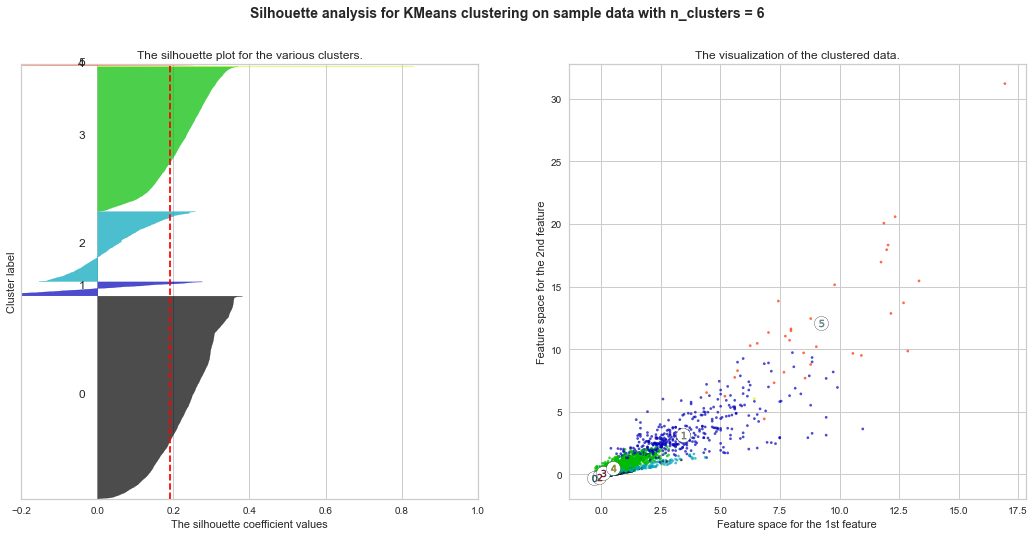

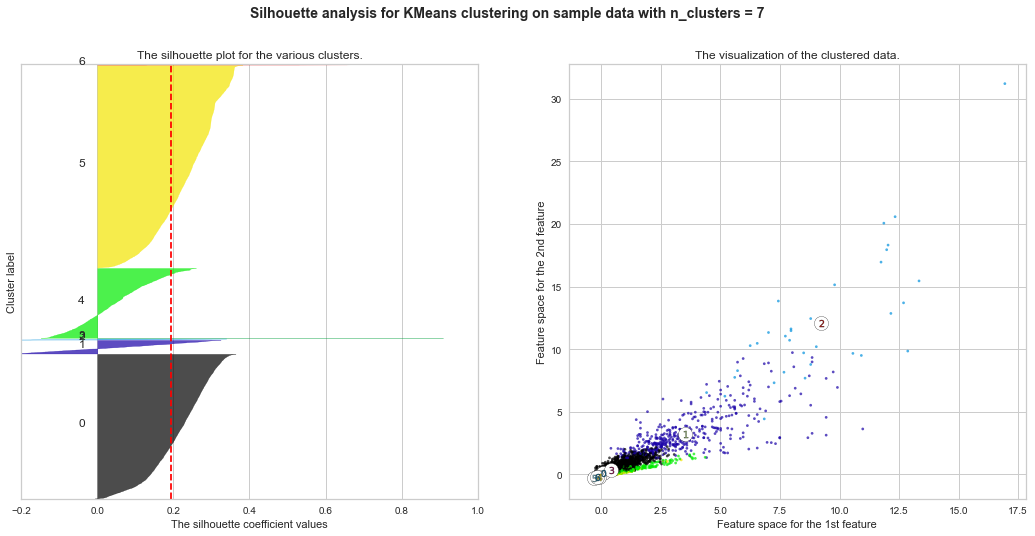

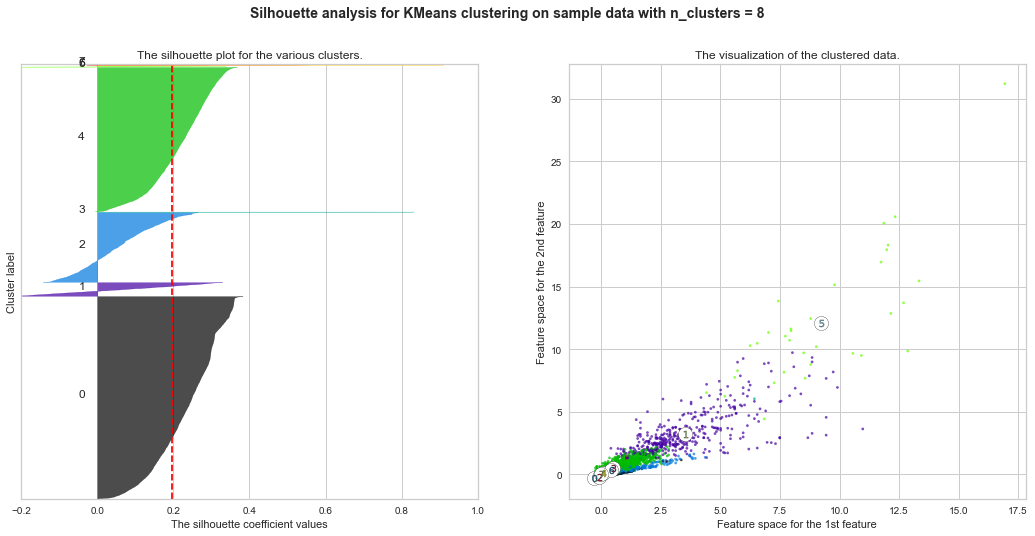

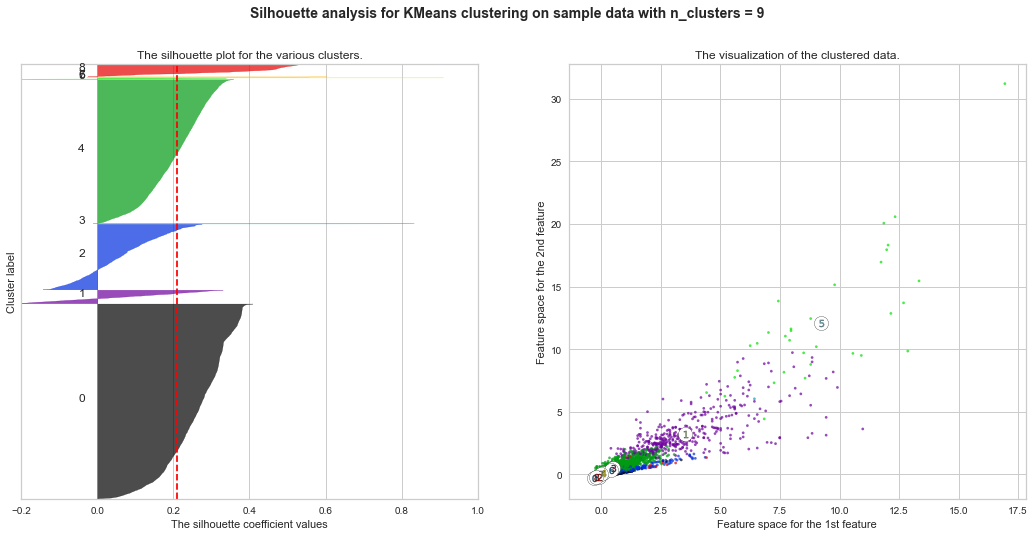

In [87]:
#Silhouette Plots for Different No. of Clusters
import matplotlib.cm as cm
for n_clusters in range(2, 10):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 8)
    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but here the range is from -0.2 till 1
    ax1.set_xlim([-0.2, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(data_scaled) + (n_clusters + 1) * 10])
    # Initialize the clusterer with n_clusters value and a random generator seed of 12345 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters,max_iter=1000, random_state=12345)
    cluster_labels = clusterer.fit_predict(data_scaled)
    # The silhouette_score gives the average value for all the samples
    # This gives a perspective into the density and separation of the formed clusters
    silhouette_avg = silhouette_score(data_scaled, cluster_labels)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(data_scaled, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels
    ax1.set_xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(data_scaled[:, 0], data_scaled[:, 1], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o', c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data with n_clusters = %d" % n_clusters), fontsize=14, fontweight='bold')

plt.show()

In [88]:
cluster_labels = km_3.fit_predict(data_scaled)

In [89]:
preds = km_3.labels_
data_df = pd.DataFrame(data)
data_df['KM_Clusters'] = preds
data_df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,KM_Clusters
0,-0.128741,-0.240949,-0.191785,0.435770,-0.710371,-0.322177,-0.569270,-0.314132,-0.466821,-0.261152,...,-0.123058,3.116284,-0.075319,0.687092,-0.068113,-0.015901,0.289069,0.0,-0.109527,0
1,0.107514,0.109065,-0.044891,1.162167,0.609609,0.016769,-0.309302,-0.215433,0.450744,-0.261152,...,-0.123058,-0.202789,-0.075319,-0.343121,-0.068113,-0.015901,-0.729790,0.0,-0.109527,1
2,-0.010614,-0.055648,-0.164069,1.041101,0.158334,-0.316744,-0.439799,-0.314473,-0.394633,-0.261152,...,0.155933,5.107727,-0.075319,-0.343121,-0.068113,-0.015901,-0.729790,0.0,-0.109527,0
3,0.698151,0.067887,-0.161605,1.041101,-0.657185,-0.615560,-0.326869,-0.312225,0.398318,-0.261152,...,0.016437,-0.202789,-0.075319,0.000284,-0.068113,-0.015901,0.458879,0.0,-0.109527,0
4,0.107514,0.026709,-0.065524,0.859502,0.203462,-0.057688,-0.336280,-0.209559,2.774322,-0.261152,...,-0.123058,-0.202789,-0.075319,-0.343121,-0.068113,-0.015901,0.242757,0.0,-0.109527,0
5,8.081116,8.591753,8.219625,1.162167,1.508141,1.464327,7.100615,6.991259,-0.081817,-0.220204,...,2.666857,-0.202789,4.064357,0.644755,1.919998,-0.015901,2.762941,0.0,-0.109527,2
6,-0.069677,-0.158593,-0.176079,1.010834,-0.291531,-0.309953,-0.531472,-0.324269,0.635369,-0.261152,...,-0.123058,-0.202789,-0.075319,0.558315,-0.068113,-0.015901,0.607462,0.0,-0.109527,1
7,-0.010614,-0.138004,-0.200407,-0.018228,-0.338069,-0.477018,-0.360083,-0.294983,-0.707448,-0.261152,...,-0.123058,-0.202789,-0.075319,1.259432,4.539255,-0.015901,2.439992,0.0,-0.109527,0
8,-0.424060,-0.343894,-0.278319,-0.774891,-0.710371,-0.725579,-0.616434,-0.405763,0.543813,-0.261152,...,-0.123058,-0.202789,-0.075319,-0.343121,-0.068113,-0.015901,2.836215,0.0,-0.109527,0
9,3.356019,2.579751,1.270373,1.131900,0.609609,0.087336,1.878026,0.946717,0.540078,-0.261152,...,-0.123058,-0.202789,-0.075319,-0.343121,-0.068113,-0.015901,-0.675759,0.0,-0.109527,1


In [92]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

In [93]:
y = data_df['KM_Clusters']
print(y)

0        0
1        1
2        0
3        0
4        0
        ..
13234    0
13235    0
13236    0
13237    0
13238    0
Name: KM_Clusters, Length: 13239, dtype: int32


In [94]:
transformed_df = data_df.drop(columns=['KM_Clusters'])
print(transformed_df)

             0         1         2         3         4         5         6   \
0     -0.128741 -0.240949 -0.191785  0.435770 -0.710371 -0.322177 -0.569270   
1      0.107514  0.109065 -0.044891  1.162167  0.609609  0.016769 -0.309302   
2     -0.010614 -0.055648 -0.164069  1.041101  0.158334 -0.316744 -0.439799   
3      0.698151  0.067887 -0.161605  1.041101 -0.657185 -0.615560 -0.326869   
4      0.107514  0.026709 -0.065524  0.859502  0.203462 -0.057688 -0.336280   
...         ...       ...       ...       ...       ...       ...       ...   
13234 -0.483123 -0.364483 -0.280783 -1.531554 -0.710371 -0.701130  0.877724   
13235 -0.483123 -0.364483 -0.272160 -1.531554 -0.710371 -0.358850  0.877724   
13236 -0.483123 -0.364483 -0.282939 -1.531554 -0.710371 -0.786700  0.877724   
13237 -0.483123 -0.364483 -0.275240 -1.531554 -0.710371 -0.481093  0.877724   
13238 -0.483123 -0.364483 -0.275240 -1.531554 -0.710371 -0.481093  0.877724   

             7         8         9   ...        19 

In [95]:
features_train, features_test, target_train, target_test = train_test_split(transformed_df, y, test_size=.25, random_state=6)

In [105]:
#Models
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Model Evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn import metrics

import warnings
warnings.filterwarnings("ignore")

In [101]:
features = transformed_df
Y = y

In [102]:
X_train, X_test, Y_train, Y_test=train_test_split(features,Y,test_size=0.2,random_state=0)

In [103]:
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(10591, 29) (10591,)
(2648, 29) (2648,)


In [106]:
classifier_Obj_LR = LogisticRegression()
classifier_Obj_LR.fit(X_train, Y_train)

modelAccuracies_LR = cross_val_score(estimator=classifier_Obj_LR, X=X_train, y=Y_train.values.ravel(),cv=10)
print("Mean score accuracy: ", modelAccuracies_LR.mean())
print("95% confidence interval: ", modelAccuracies_LR.std())

Mean score accuracy:  0.9699739875639176
95% confidence interval:  0.0037042670010451473


In [108]:
print("The overall accuracy of the model: %0.2f (+/- %0.2f)" % (modelAccuracies_LR.mean(), modelAccuracies_LR.std() * 2))

The overall accuracy of the model: 0.97 (+/- 0.01)


In [109]:
y_pred_LR = classifier_Obj_LR.predict(X_test)

In [110]:
print(metrics.classification_report(Y_test, y_pred_LR))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1675
           1       0.96      0.96      0.96       952
           2       0.95      0.90      0.93        21

    accuracy                           0.97      2648
   macro avg       0.96      0.95      0.96      2648
weighted avg       0.97      0.97      0.97      2648



In [111]:
cm_LR = confusion_matrix(Y_test, y_pred_LR)
print("This is the confusion matrix: ")
print(cm_LR)

This is the confusion matrix: 
[[1641   34    0]
 [  34  917    1]
 [   0    2   19]]


In [112]:
classifierObj_NB = BernoulliNB()
classifierObj_NB.fit(X_train, Y_train)

modelAccuracies_NB = cross_val_score(estimator=classifierObj_NB, X=X_train, y=Y_train.values.ravel(),cv=10)
print("Mean score accuracy: ", modelAccuracies_NB.mean())
print("95% confidence interval: ", modelAccuracies_NB.std())

Mean score accuracy:  0.8798034813904183
95% confidence interval:  0.007194090348951982


In [113]:
print("The overall accuracy of the model: %0.2f (+/- %0.2f)" % (modelAccuracies_NB.mean(), modelAccuracies_NB.std() * 2))

The overall accuracy of the model: 0.88 (+/- 0.01)


In [114]:
y_pred_NB = classifierObj_NB.predict(X_test)

In [115]:
print(metrics.classification_report(Y_test, y_pred_NB))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1675
           1       0.89      0.77      0.82       952
           2       0.24      1.00      0.39        21

    accuracy                           0.88      2648
   macro avg       0.68      0.90      0.71      2648
weighted avg       0.90      0.88      0.89      2648



In [116]:
cm_NB = confusion_matrix(Y_test, y_pred_NB)
print("This is the confusion matrix: ")
print(cm_NB)

This is the confusion matrix: 
[[1583   91    1]
 [ 158  730   64]
 [   0    0   21]]


In [117]:
classifier_Obj_Randfor = RandomForestClassifier(bootstrap=False, criterion='entropy', n_estimators=40)
classifier_Obj_Randfor.fit(X_train, Y_train)

modelAccuracies_RF = cross_val_score(estimator=classifier_Obj_Randfor, X=X_train, y=Y_train.values.ravel(),cv=10)
print("Mean score accuracy: ", modelAccuracies_RF.mean())
print("95% confidence interval: ", modelAccuracies_RF.std())

Mean score accuracy:  0.9695971635754628
95% confidence interval:  0.0050793772976083


In [118]:
print("The overall accuracy of the model: %0.2f (+/- %0.2f)" % (modelAccuracies_RF.mean(), modelAccuracies_RF.std() * 2))

The overall accuracy of the model: 0.97 (+/- 0.01)


In [119]:
y_pred_RF = classifier_Obj_Randfor.predict(X_test)

In [120]:
print(metrics.classification_report(Y_test, y_pred_RF))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1675
           1       0.95      0.96      0.95       952
           2       1.00      0.86      0.92        21

    accuracy                           0.97      2648
   macro avg       0.97      0.93      0.95      2648
weighted avg       0.97      0.97      0.97      2648



In [121]:
cm_RF = confusion_matrix(Y_test, y_pred_RF)
print("This is the confusion matrix: ")
print(cm_RF)

This is the confusion matrix: 
[[1626   49    0]
 [  38  914    0]
 [   0    3   18]]
